    Import the data and get infromation

In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [140]:
data=pd.read_csv("children_anemia_adjusted.csv",sep=";")
data

,Age in 5-year groups,Type of place of residence,Highest educational level,Wealth index combined,Births in last five years,Age of respondent at 1st birth,Have mosquito bed net for sleeping (from household questionnaire),Smokes cigarettes,Current marital status,Currently residing with husband/partner,Had fever in last two weeks,Hemoglobin level adjusted for altitude (g/dl - 1 decimal),"Taking iron pills, sprinkles or syrup",Anemia level
0,40-44,Urban,Higher,Richest,1,22,Yes,No,Living with partner,Staying elsewhere,No,NaN,Yes,NaN
1,35-39,Urban,Higher,Richest,1,28,Yes,No,Married,Living with her,No,NaN,No,NaN
2,25-29,Urban,Higher,Richest,1,26,No,No,Married,Living with her,No,NaN,No,NaN
3,25-29,Urban,Secondary,Richest,1,25,Yes,No,Married,Living with her,No,114.0,No,Not anemic
4,20-24,Urban,Secondary,Richest,1,21,Yes,No,No longer living together/separated,NaN,No,NaN,No,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33919,35-39,Rural,Secondary,Richer,2,19,Yes,No,Married,Living with her,No,120.0,Yes,Not anemic
33920,25-29,Rural,No education,Richer,1,27,Yes,No,Never in union,NaN,No,120.0,No,Not anemic
33921,25-29,Rural,Higher,Richer,1,22,Yes,No,Married,Living with her,No,119.0,No,Not anemic
33922,20-24,Rural,Secondary,Richer,1,21,Yes,No,Married,Living with her,No,75.0,Yes,Moderate


In [141]:
data.describe()

,Births in last five years,Age of respondent at 1st birth,Hemoglobin level adjusted for altitude (g/dl - 1 decimal)
count,33924.000000,33924.000000,10182.000000
mean,1.823783,19.570776,101.270183
std,0.705460,4.313172,15.569583
min,1.000000,12.000000,29.000000
25%,1.000000,16.000000,92.000000
50%,2.000000,19.000000,103.000000
75%,2.000000,22.000000,112.000000
max,6.000000,48.000000,170.000000


    Data Preprocessing

Since most of the feature are categorical we are going to skip the data distribution so we will take care of the missing value and then moves to the encoding part 

Taking care of missing values

In [142]:
data.isnull().sum()

Age in 5-year groups                                                     0
Type of place of residence                                               0
Highest educational level                                                0
Wealth index combined                                                    0
Births in last five years                                                0
Age of respondent at 1st birth                                           0
Have mosquito bed net for sleeping (from household questionnaire)        0
Smokes cigarettes                                                        0
Current marital status                                                   0
Currently residing with husband/partner                               1698
Had fever in last two weeks                                           3211
Hemoglobin level adjusted for altitude (g/dl - 1 decimal)            23742
Taking iron pills, sprinkles or syrup                                 3211
Anemia level             

In [143]:
#We drop all the line that don't have a result in the last column
data=data.dropna(subset=['Anemia level'])

In [144]:
data.isnull().sum()

Age in 5-year groups                                                   0
Type of place of residence                                             0
Highest educational level                                              0
Wealth index combined                                                  0
Births in last five years                                              0
Age of respondent at 1st birth                                         0
Have mosquito bed net for sleeping (from household questionnaire)      0
Smokes cigarettes                                                      0
Current marital status                                                 0
Currently residing with husband/partner                              518
Had fever in last two weeks                                            0
Hemoglobin level adjusted for altitude (g/dl - 1 decimal)              0
Taking iron pills, sprinkles or syrup                                  0
Anemia level                                       

In [145]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10182 entries, 3 to 33922
Data columns (total 14 columns):
 #   Column                                                             Non-Null Count  Dtype  
---  ------                                                             --------------  -----  
 0   Age in 5-year groups                                               10182 non-null  object 
 1   Type of place of residence                                         10182 non-null  object 
 2   Highest educational level                                          10182 non-null  object 
 3   Wealth index combined                                              10182 non-null  object 
 4   Births in last five years                                          10182 non-null  int64  
 5   Age of respondent at 1st birth                                     10182 non-null  int64  
 6   Have mosquito bed net for sleeping (from household questionnaire)  10182 non-null  object 
 7   Smokes cigarettes          

In [146]:
#We use the simpleImputer to fill the missing values in the column "Currently residing with husband/partner"
from sklearn.impute import SimpleImputer
#We will use the most frequent strategy
imputer= SimpleImputer(strategy='most_frequent')
data["Currently residing with husband/partner"] = imputer.fit_transform(data[["Currently residing with husband/partner"]])[:,0]


C:\Users\steph\AppData\Local\Temp\ipykernel_29600\1034181233.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["Currently residing with husband/partner"] = imputer.fit_transform(data[["Currently residing with husband/partner"]])[:,0]


In [147]:
data.isnull().sum()
#No more missing values

Age in 5-year groups                                                 0
Type of place of residence                                           0
Highest educational level                                            0
Wealth index combined                                                0
Births in last five years                                            0
Age of respondent at 1st birth                                       0
Have mosquito bed net for sleeping (from household questionnaire)    0
Smokes cigarettes                                                    0
Current marital status                                               0
Currently residing with husband/partner                              0
Had fever in last two weeks                                          0
Hemoglobin level adjusted for altitude (g/dl - 1 decimal)            0
Taking iron pills, sprinkles or syrup                                0
Anemia level                                                         0
dtype:

In [148]:
data

,Age in 5-year groups,Type of place of residence,Highest educational level,Wealth index combined,Births in last five years,Age of respondent at 1st birth,Have mosquito bed net for sleeping (from household questionnaire),Smokes cigarettes,Current marital status,Currently residing with husband/partner,Had fever in last two weeks,Hemoglobin level adjusted for altitude (g/dl - 1 decimal),"Taking iron pills, sprinkles or syrup",Anemia level
3,25-29,Urban,Secondary,Richest,1,25,Yes,No,Married,Living with her,No,114.0,No,Not anemic
5,30-34,Urban,Higher,Richest,1,30,Yes,No,Married,Living with her,No,119.0,No,Not anemic
6,35-39,Urban,Secondary,Richest,2,32,Yes,No,Married,Living with her,No,102.0,Yes,Mild
9,20-24,Urban,Secondary,Richest,1,19,Yes,No,Married,Living with her,No,113.0,Yes,Not anemic
12,25-29,Urban,Higher,Richest,1,24,Yes,No,Married,Living with her,No,109.0,No,Mild
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33918,35-39,Rural,Secondary,Richer,2,19,Yes,No,Married,Living with her,No,108.0,Yes,Mild
33919,35-39,Rural,Secondary,Richer,2,19,Yes,No,Married,Living with her,No,120.0,Yes,Not anemic
33920,25-29,Rural,No education,Richer,1,27,Yes,No,Never in union,Living with her,No,120.0,No,Not anemic
33921,25-29,Rural,Higher,Richer,1,22,Yes,No,Married,Living with her,No,119.0,No,Not anemic


In [149]:
X=data.iloc[:,:-1].values
y=data.iloc[:,-1].values

In [ ]:
X.hist(bins=20,figsize=(10,10))
plt.show()

Encoding the categorical Data

In [150]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct=ColumnTransformer(transformers=[('encoder',
                                    OneHotEncoder(),
                                    [0,1,2,3,6,7,8,9,10,12])],
                                    remainder='passthrough')

X=np.array(ct.fit_transform(X))

In [151]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
y=le.fit_transform(y)

Splitting into test an train sets

In [153]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,
                                               test_size=0.25,
                                               random_state=0)

In [154]:
print(X_train)

[[0.0 0.0 0.0 ... 1 25 117.0]
 [0.0 1.0 0.0 ... 2 20 105.0]
 [0.0 0.0 1.0 ... 1 18 88.0]
 ...
 [0.0 0.0 1.0 ... 2 21 114.0]
 [0.0 0.0 0.0 ... 2 30 112.0]
 [0.0 0.0 0.0 ... 2 22 94.0]]


Feature scaling

In [155]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train[:,3:]=sc.fit_transform(X_train[:,3:])
X_test[:,3:]=sc.transform(X_test[:,3:])

    Principal Component Analysis

In [156]:
from sklearn.decomposition import PCA
pca=PCA()
pca.fit_transform(X_train)

array([[ 1.56351941e+00, -6.83140348e-03, -1.68647329e+00, ...,
        -6.54419788e-16,  7.70021367e-16, -2.18398191e-15],
       [-1.58999509e+00, -3.02551879e-01, -4.69159751e-01, ...,
        -1.41928519e-15, -2.45559534e-16, -2.03690886e-15],
       [ 3.44433316e-01,  4.86164331e+00,  8.99725209e-01, ...,
        -8.80104437e-16,  1.49219891e-15,  1.17069548e-15],
       ...,
       [ 2.99917172e-01, -3.36903848e-01, -2.76503488e-01, ...,
        -2.63379226e-17, -2.73456809e-17, -3.01837998e-17],
       [ 3.61490991e+00, -2.61864926e+00,  1.74821219e+00, ...,
         3.25225441e-17,  1.31817773e-16,  5.19578301e-18],
       [-6.61719005e-01, -8.40781110e-01,  5.72283518e-02, ...,
         1.01155123e-18, -7.79207135e-17, -5.74531893e-17]])

In [157]:
pca.n_components_

39

In [158]:
eig = pd.DataFrame(
    {
        "Dimension" : ["Dim" + str(x+1) for x in range(39)],
        "Explained Variance" : pca.explained_variance_,
        "% explained variance" : np.round(pca.explained_variance_ratio_*100),
        "% cumulative expl. variance" : np.round(np.cumsum(pca.explained_variance_ratio_)*100)
    }
)
eig.head()

,Dimension,Explained Variance,% explained variance,% cumulative expl. variance
0,Dim1,3.926100,11.0,11.0
1,Dim2,2.174996,6.0,17.0
2,Dim3,2.073104,6.0,22.0
3,Dim4,2.004688,6.0,28.0
4,Dim5,1.906008,5.0,33.0


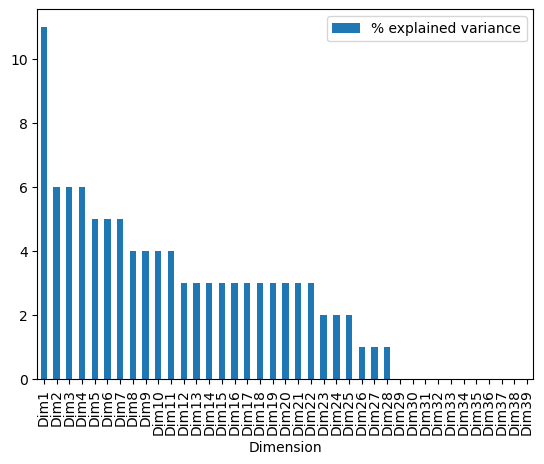

In [159]:
eig.plot.bar(x="Dimension", y="% explained variance")
plt.show()

In [160]:
n_cps = 4
pca = PCA(n_components=n_cps)

X_train = pd.DataFrame(
    data=pca.fit_transform(X_train),
    columns=['PCA1','PCA2','PCA3','PCA4']
)
X_test = pd.DataFrame(
    data=pca.fit_transform(X_test),
    columns=['PCA1','PCA2','PCA3','PCA4']
)

X_train.head()

,PCA1,PCA2,PCA3,PCA4
0,1.562926,-0.034248,-1.780630,0.040438
1,-1.592467,-0.333573,-0.638853,0.605008
2,0.342650,4.875932,1.084423,-0.472433
3,1.568176,0.831989,-0.330943,0.151481
4,-0.337368,-0.307490,0.082818,0.288815


In [161]:
#Let's see the most important features
most_important=[np.abs(pca.components_[i]).argmax() for i in range(n_cps) ]
print(most_important)

[7, 24, 29, 18]


    Model Training

Logistic regression

In [162]:
from sklearn.linear_model import LogisticRegression
logistic=LogisticRegression(random_state=0)
logistic.fit(X_train,y_train)

LogisticRegression(random_state=0)

K-Nearest Neighborhood

In [163]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier()
knn.fit(X_train,y_train)

KNeighborsClassifier()

SVC

In [164]:
from sklearn.svm import SVC
svc=SVC(kernel='linear',random_state=0)
svc.fit(X_train,y_train)

SVC(kernel='linear', random_state=0)

Decision Tree

In [165]:
from sklearn.tree import DecisionTreeClassifier
dtree=DecisionTreeClassifier(criterion='entropy',random_state=0)
dtree.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy', random_state=0)

Random Forest

In [166]:
from sklearn.ensemble import RandomForestClassifier
rforest=RandomForestClassifier(n_estimators=10,
                               criterion='entropy',
                               random_state=0)
rforest.fit(X_train,y_train)

RandomForestClassifier(criterion='entropy', n_estimators=10, random_state=0)

    Predict a new result

In [167]:
#New input
patient_1=[["30-34","Urban","Higher","Richest",1,30,"Yes","No","Married","Living with her","No",119.0,"No"]]
patient_2=[["30-34","Urban","Secondary","Richest",2,32,"Yes","No","Married","Living with her","No",102.0,"Yes"]]

In [168]:
#Pipeline
def pineline(X):
    X=np.array(ct.transform(X))
    X[:,3:]=sc.transform(X[:,3:])
    X=pd.DataFrame(data=pca.transform(X),columns=['PCA1','PCA2','PCA3','PCA4'])
    return X

In [173]:
# To see all the labels
original_labels = le.classes_
encoded_labels = list(range(len(original_labels)))

for original, encoded in zip(original_labels, encoded_labels):
    print(f" {original} : {encoded}")

 Mild : 0
 Moderate : 1
 Not anemic : 2
 Severe : 3


In [169]:
#Predictions
patient_1=pineline(patient_1)
patient_2=pineline(patient_2)
print("Patient 1:",logistic.predict(patient_1))
print("Patient 2:",logistic.predict(patient_2))
print("------------------------------")
print("Patient 1:",knn.predict(patient_1))
print("Patient 2:",knn.predict(patient_2))
print("------------------------------")
print("Patient 1:",svc.predict(patient_1))
print("Patient 2:",svc.predict(patient_2))
print("------------------------------")
print("Patient 1:",dtree.predict(patient_1))
print("Patient 2:",dtree.predict(patient_2))
print("------------------------------")
print("Patient 1:",rforest.predict(patient_1))
print("Patient 2:",rforest.predict(patient_2))

Patient 1: [2]
Patient 2: [2]
------------------------------
Patient 1: [1]
Patient 2: [2]
------------------------------
Patient 1: [2]
Patient 2: [2]
------------------------------
Patient 1: [2]
Patient 2: [0]
------------------------------
Patient 1: [0]
Patient 2: [0]


    Predicting the test result and visuals

Logistic regression

In [174]:
y_log=logistic.predict(X_test)
print(np.concatenate(
    (y_log.reshape(len(y_log),1), y_test.reshape(len(y_test),1)),1)
)

[[1 1]
 [2 2]
 [2 1]
 ...
 [2 2]
 [2 2]
 [2 2]]


KNN

In [176]:
y_knn=knn.predict(X_test)
print(np.concatenate(
    (y_knn.reshape(len(y_knn),1), y_test.reshape(len(y_test),1)),1)
)

[[1 1]
 [0 2]
 [0 1]
 ...
 [2 2]
 [1 2]
 [2 2]]


SVC

In [177]:
y_svc=svc.predict(X_test)
print(np.concatenate(
    (y_svc.reshape(len(y_svc),1), y_test.reshape(len(y_test),1)),1)
)

[[1 1]
 [2 2]
 [2 1]
 ...
 [2 2]
 [2 2]
 [2 2]]


Decision Tree

In [178]:
y_dtree=dtree.predict(X_test)
print(np.concatenate(
    (y_dtree.reshape(len(y_dtree),1), y_test.reshape(len(y_test),1)),1)
)

[[1 1]
 [1 2]
 [0 1]
 ...
 [0 2]
 [1 2]
 [2 2]]


Random Forest 

In [179]:
y_rforest=rforest.predict(X_test)
print(np.concatenate(
    (y_rforest.reshape(len(y_rforest),1), y_test.reshape(len(y_test),1)),1)
)

[[1 1]
 [1 2]
 [0 1]
 ...
 [2 2]
 [1 2]
 [2 2]]


    Model Evaluation

In [180]:
from sklearn.metrics import f1_score, precision_score, recall_score

In [182]:
print("logistic_f1: {:.2f} logistic_precision: {:.2f} logistic_recall: {:.2f}".format(
    f1_score(y_test, y_log, average='weighted'),
    precision_score(y_test, y_log, average='weighted'),
    recall_score(y_test, y_log, average='weighted')
))
print("--------------------------------")
print("knn_f1: {:.2f} knn_precision: {:.2f} knn_recall: {:.2f}".format(
    f1_score(y_test, y_knn, average='weighted'),
    precision_score(y_test, y_knn, average='weighted'),
    recall_score(y_test, y_knn, average='weighted')
))
print("--------------------------------")
print("svc_f1: {:.2f} svc_precision: {:.2f} svm_recall: {:.2f}".format(
    f1_score(y_test, y_svc, average='weighted'),
    precision_score(y_test, y_svc, average='weighted'),
    recall_score(y_test, y_svc, average='weighted')
))
print("--------------------------------")
print("tree_f1: {:.2f} tree_precision: {:.2f} tree_recall: {:.2f}".format(
    f1_score(y_test, y_dtree, average='weighted'),
    precision_score(y_test, y_dtree, average='weighted'),
    recall_score(y_test, y_dtree, average='weighted')
))
print("--------------------------------")
print("forest_f1: {:.2f} forest_precision: {:.2f} forest_recall: {:.2f}".format(
    f1_score(y_test, y_rforest, average='weighted'),
    precision_score(y_test, y_rforest, average='weighted'),
    recall_score(y_test, y_rforest, average='weighted')
))


logistic_f1: 0.39 logistic_precision: 0.33 logistic_recall: 0.47
--------------------------------
knn_f1: 0.37 knn_precision: 0.37 knn_recall: 0.37
--------------------------------
svc_f1: 0.38 svc_precision: 0.33 svm_recall: 0.46
--------------------------------
tree_f1: 0.35 tree_precision: 0.37 tree_recall: 0.34
--------------------------------
forest_f1: 0.38 forest_precision: 0.39 forest_recall: 0.38


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


    Conclusion

In this case the best model is logistic regression because it has the highest recall of all the model and since we analysing chance to have an illnessthis metrics is the most important